## Notebook 06 - Spectral Centroid Analysis

### Objective
The spectral centroid represents the "centre of mass" of the spectrum and is often interpreted as a measure of spectral brightness.

This notebook investigates whether spectral statistics can distinguish between:
- Normal recordings
- Overlapping (subtle) anomalies
- Obvious anomalies

### Imports

In [39]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from src.config import *
from src.io import *
from src.feature import *
from src.visualization import *
from src.utils import *

### Loading RMS Results

In [2]:
rms_summary = pd.read_csv(results_path/"rms_summary.csv")
group_a = pd.read_csv(results_path/"group_a.csv")
group_b = pd.read_csv(results_path/"group_b.csv")
group_c = pd.read_csv(results_path/"group_c.csv")


### Computing Spectral Centroid Statistics

In [3]:
records = []
for _, row in rms_summary.iterrows():
    file_path = get_audio_path(row['file_name'], row['label'])
    signal, sr = load_channel(file_path)
    stats = spectral_centroid_statistics(signal, sr)
    stats["file_name"] = row["file_name"]
    stats["label"] = row["label"]
    records.append(stats)

centroid_summary = pd.DataFrame(records)

In [12]:
centroid_summary.to_csv(results_path/"spectral_centroid_summary.csv", index = False)

In [4]:
df = pd.read_csv(results_path/"spectral_centroid_summary.csv")

In [17]:
df.head()

,centroid_mean,centroid_std,centroid_min,centroid_max,centroid_delta,centroid_q25,centroid_q75,centroid_iqr,file_name,label
0,2377.057822,203.249647,1962.135768,3639.686883,1677.551115,2243.546767,2495.872024,252.325257,00000000.wav,Normal
1,2615.976632,163.012387,2204.683950,3477.425155,1272.741205,2504.840504,2701.621417,196.780913,00000001.wav,Normal
2,2420.451821,221.444349,1879.446225,3125.582353,1246.136128,2277.626044,2554.681328,277.055284,00000002.wav,Normal
3,2640.560590,143.981090,2293.331119,3325.892444,1032.561324,2548.801170,2723.995983,175.194813,00000003.wav,Normal
4,2363.787353,161.885214,2017.350298,3058.560910,1041.210611,2262.940960,2441.204920,178.263960,00000004.wav,Normal


In [18]:
df.tail()

,centroid_mean,centroid_std,centroid_min,centroid_max,centroid_delta,centroid_q25,centroid_q75,centroid_iqr,file_name,label
1144,2785.119551,135.144717,2331.756014,3181.062491,849.306476,2682.875307,2880.668404,197.793096,00000138.wav,Abnormal
1145,2803.357429,93.263251,2567.790242,3145.139984,577.349741,2724.876218,2874.065519,149.189301,00000139.wav,Abnormal
1146,2506.783220,129.574897,2159.921562,2766.565755,606.644193,2436.032236,2597.635127,161.602891,00000140.wav,Abnormal
1147,1942.928859,368.366901,1143.906955,2844.171474,1700.264519,1543.008364,2197.485885,654.477522,00000141.wav,Abnormal
1148,1799.422214,443.002339,1102.833628,2718.733562,1615.899935,1414.784700,2158.481049,743.696348,00000142.wav,Abnormal


In [5]:
# Isolating label 'Normal'
normal_label_data = df.loc[df['label'] == 'Normal']
# Isolating label 'Abnormal'
abnormal_label_data = df.loc[df['label'] == 'Abnormal']

In [24]:
# getting describe() function for Normal label
normal_label_data.describe()

,centroid_mean,centroid_std,centroid_min,centroid_max,centroid_delta,centroid_q25,centroid_q75,centroid_iqr
count,1006.000000,1006.000000,1006.000000,1006.000000,1006.000000,1006.000000,1006.000000,1006.000000
mean,2324.484551,183.151164,1902.541404,3144.268907,1241.727504,2202.686963,2421.615822,218.928860
std,254.308739,41.764979,261.803361,315.434281,307.999657,263.936347,257.204440,64.628326
min,1856.718440,95.219144,1242.403004,2339.347071,553.270456,1701.437257,1963.047869,112.092435
25%,2134.132966,154.709284,1706.864966,2934.092198,1018.997649,1998.564159,2237.284482,180.944483
50%,2327.511140,179.972412,1887.044671,3128.784483,1200.226543,2208.067690,2421.966083,211.075411
75%,2489.855213,204.795000,2070.884760,3338.195511,1412.755820,2372.551791,2583.304965,247.388790
max,3538.405234,558.329638,3209.865380,4369.755726,2663.609953,3449.457862,3623.522730,1084.711396


In [25]:
# getting describe() function for Abnormal label
abnormal_label_data.describe()

,centroid_mean,centroid_std,centroid_min,centroid_max,centroid_delta,centroid_q25,centroid_q75,centroid_iqr
count,143.000000,143.000000,143.000000,143.000000,143.000000,143.000000,143.000000,143.000000
mean,2204.626187,207.560202,1647.468512,2853.488150,1206.019638,2068.869075,2343.292258,274.423183
std,289.824527,90.716497,283.059355,444.889636,478.040651,306.830493,305.095041,151.569262
min,1474.449353,52.780464,1049.699691,1652.720309,276.271437,1374.580014,1541.653892,64.164553
25%,1986.930880,133.777781,1457.522966,2585.074164,752.080459,1835.984542,2127.014806,172.565647
50%,2236.547943,217.171013,1581.155872,2890.174929,1247.018590,2066.093780,2376.734853,236.335435
75%,2413.533336,265.326312,1729.890632,3108.406226,1515.483974,2310.467075,2563.647155,373.138354
max,3325.888123,626.390526,2567.790242,4081.963022,2445.213986,3261.770002,3472.607938,1149.598727


### Getting group_a, group_b and group_c

In [6]:
group_a_stats = centroid_summary[
    centroid_summary.file_name.isin(group_a.file_name) &
    centroid_summary.label.isin(group_a.label)
    ]
group_b_stats = centroid_summary[
    centroid_summary.file_name.isin(group_b.file_name) &
    centroid_summary.label.isin(group_b.label)
    ]
group_c_stats = centroid_summary[
    centroid_summary.file_name.isin(group_c.file_name) &
    centroid_summary.label.isin(group_c.label)
    ]

In [79]:
group_a_stats

,centroid_mean,centroid_std,centroid_min,centroid_max,centroid_delta,centroid_q25,centroid_q75,centroid_iqr,file_name,label
317,2285.899049,201.961702,1836.507122,3191.693088,1355.185965,2159.704912,2403.260305,243.555393,00000317.wav,Normal
485,2101.931605,184.644172,1704.302849,2785.325545,1081.022696,1968.152192,2209.627407,241.475215,00000485.wav,Normal
507,2430.655952,188.772242,2005.891800,3798.648907,1792.757106,2316.474292,2494.324982,177.850690,00000507.wav,Normal
527,2031.707251,142.192385,1634.665763,2603.561471,968.895708,1935.703207,2116.466284,180.763077,00000527.wav,Normal
640,3039.382106,113.097075,2635.719782,3308.699516,672.979734,2984.026007,3118.255935,134.229928,00000640.wav,Normal


In [80]:
group_b_stats

,centroid_mean,centroid_std,centroid_min,centroid_max,centroid_delta,centroid_q25,centroid_q75,centroid_iqr,file_name,label
1099,2069.470135,122.941472,1832.500048,2825.789528,993.289480,1989.889869,2120.959476,131.069607,00000093.wav,Abnormal
1103,1963.841931,104.695306,1765.080028,2478.899896,713.819868,1902.955918,2005.071994,102.116075,00000097.wav,Abnormal
1109,2475.248149,143.253492,2192.845860,3013.542200,820.696340,2387.158490,2551.566664,164.408175,00000103.wav,Abnormal
1112,2449.870947,124.701533,2035.110897,2868.021162,832.910265,2361.682722,2524.454460,162.771739,00000106.wav,Abnormal
1114,2447.719856,128.359981,1942.262064,2832.907097,890.645032,2364.588448,2515.228909,150.640462,00000108.wav,Abnormal


In [75]:
group_c_stats

,centroid_mean,centroid_std,centroid_min,centroid_max,centroid_delta,centroid_q25,centroid_q75,centroid_iqr,file_name,label
1039,2446.062052,217.171013,1659.415871,2971.179927,1311.764056,2337.237166,2576.112744,238.875578,00000033.wav,Abnormal
1079,2515.368476,163.002630,1992.637485,2970.644100,978.006614,2416.382802,2613.791542,197.408741,00000073.wav,Abnormal
1083,2522.204610,223.099823,1624.550058,3328.400329,1703.850270,2410.565653,2631.852299,221.286646,00000077.wav,Abnormal
1086,1985.612485,129.120570,1691.613347,2272.653147,581.039800,1895.796949,2089.941217,194.144268,00000080.wav,Abnormal
1146,2506.783220,129.574897,2159.921562,2766.565755,606.644193,2436.032236,2597.635127,161.602891,00000140.wav,Abnormal


### Spectral Centroid Trajectories

In [43]:
# For Group A - Normal files

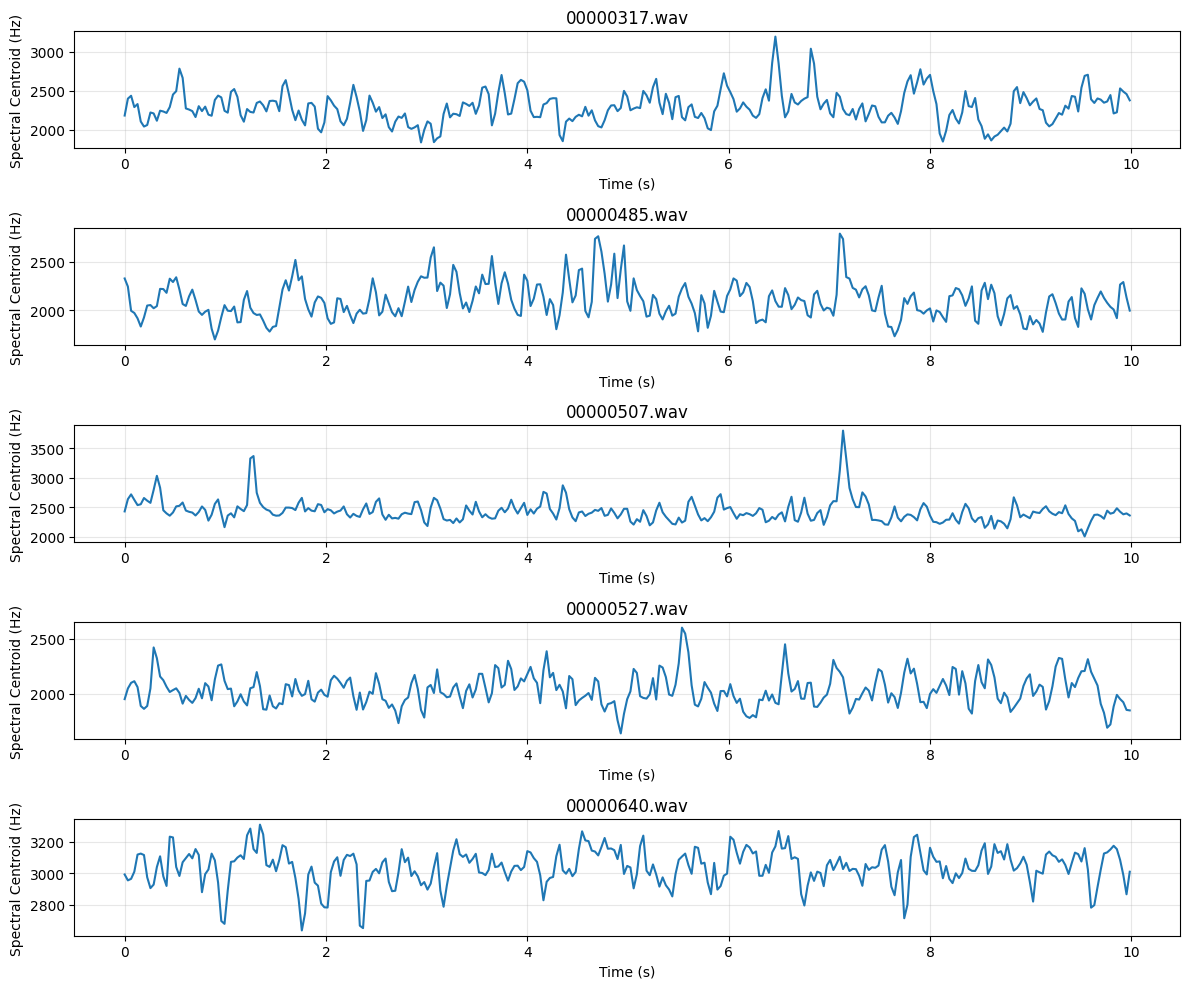

In [81]:
fig, axes = plt.subplots(5, 1, figsize = (12, 10))
for ax, (_, row) in zip(axes, group_a_stats.iterrows()):
    signal, sr = load_channel(get_audio_path(row.file_name, row.label))
    plot_spectral_centroid(signal, sr, ax = ax, title = row.file_name)
    plt.tight_layout()

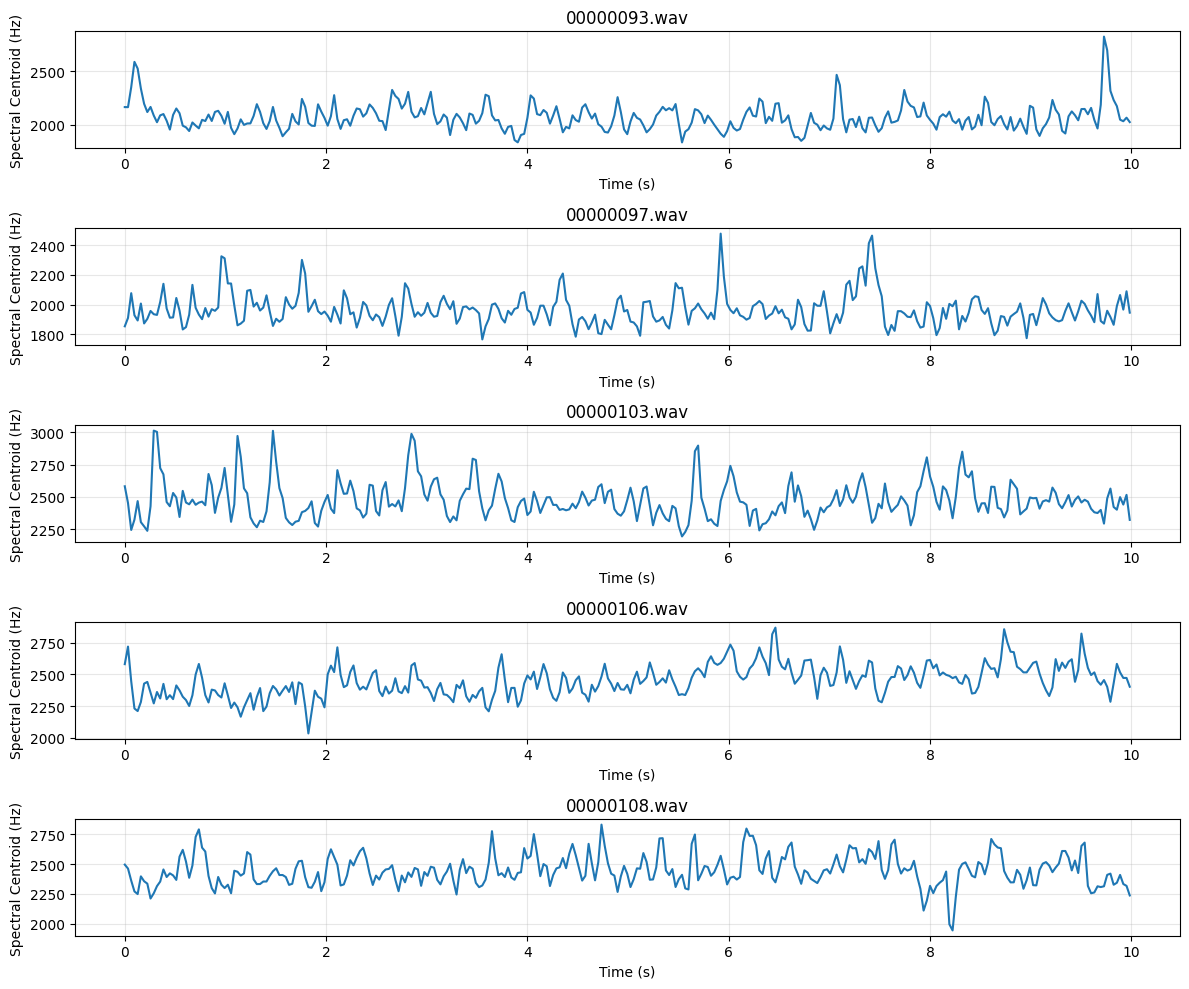

In [82]:
# For Group B - Overlapping (Subtle) Anomalies
fig, axes = plt.subplots(5, 1, figsize = (12, 10))
for ax, (_, row) in zip(axes, group_b_stats.iterrows()):
    signal, sr = load_channel(get_audio_path(row.file_name, row.label))
    plot_spectral_centroid(signal, sr, ax = ax, title = row.file_name)
    plt.tight_layout()

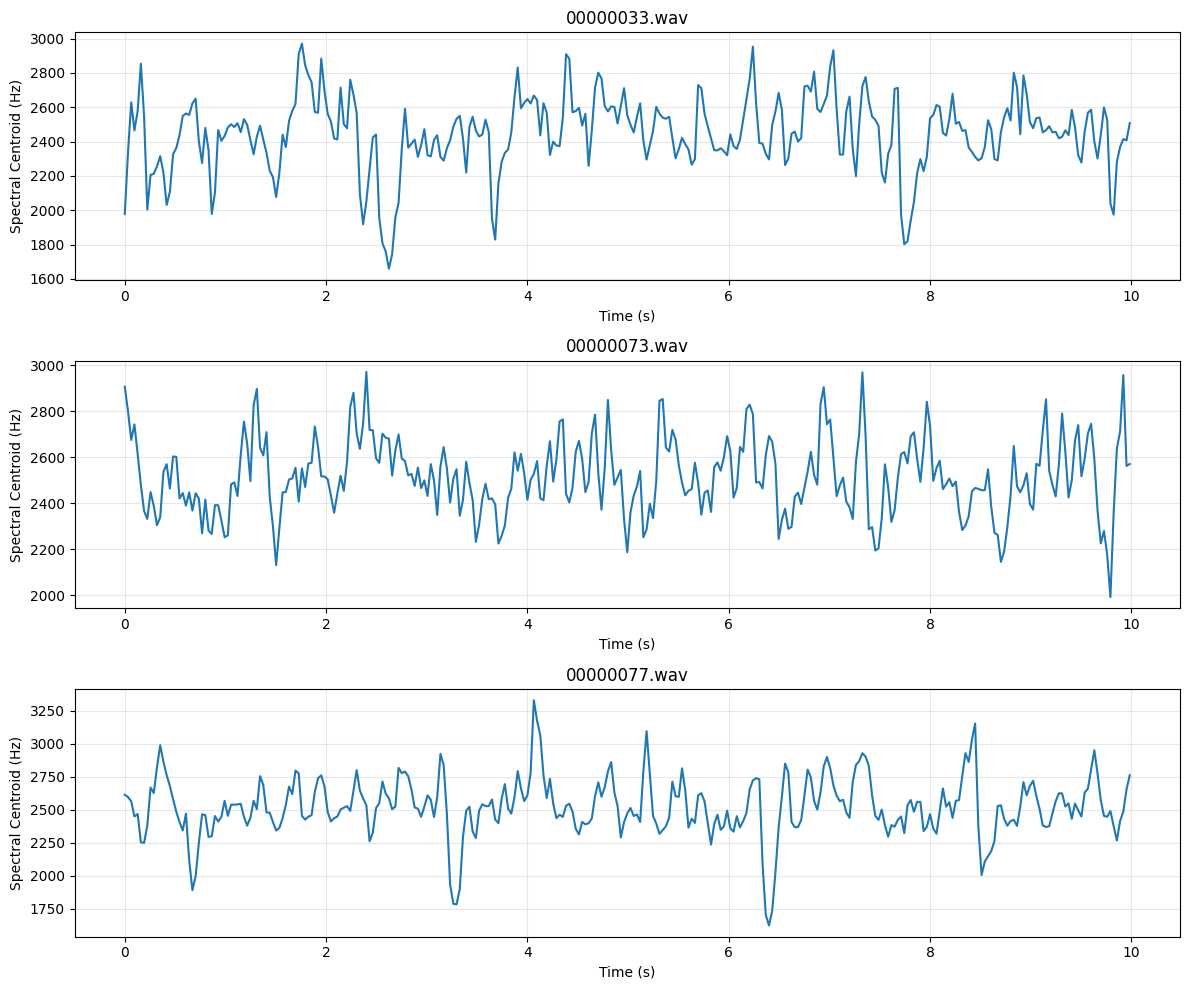

In [83]:
# For Group C - Obvious Anomalies
fig, axes = plt.subplots(3, 1, figsize = (12, 10))
for ax, (_, row) in zip(axes, group_c_stats.iterrows()):
    signal, sr = load_channel(get_audio_path(row.file_name, row.label))
    plot_spectral_centroid(signal, sr, ax = ax, title = row.file_name)
    plt.tight_layout()

### Mean Comparison

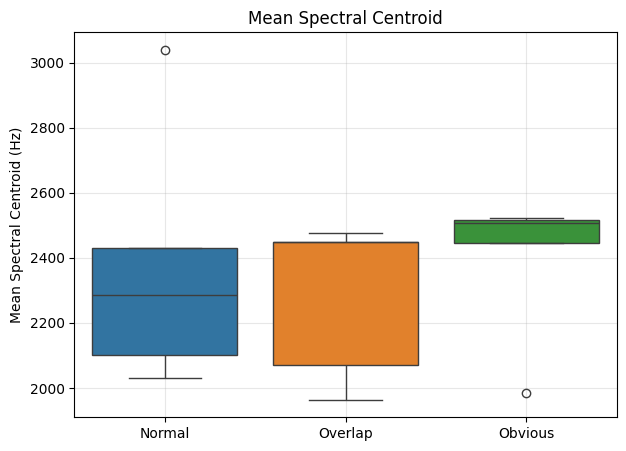

In [84]:
import seaborn as sns
plt.figure(figsize = (7, 5))
sns.boxplot(
    data = [
        group_a_stats['centroid_mean'].values,
        group_b_stats['centroid_mean'].values,
        group_c_stats['centroid_mean'].values
    ])
plt.xticks(ticks = [0, 1, 2],labels = ["Normal", "Overlap", "Obvious"])
plt.ylabel("Mean Spectral Centroid (Hz)")
plt.title("Mean Spectral Centroid")
plt.grid(alpha = 0.3)
plt.show()

### Standard Deviation

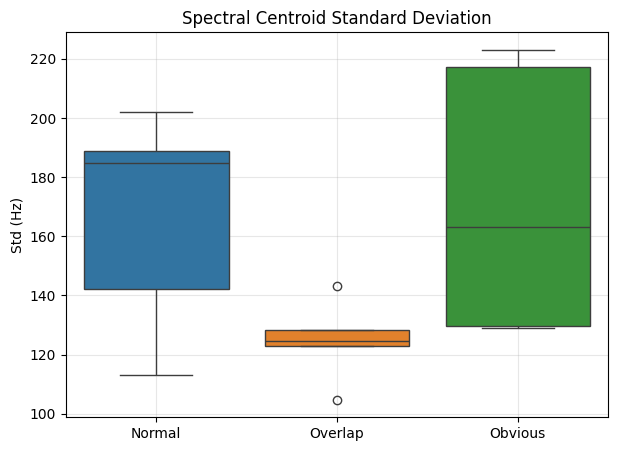

In [85]:
plt.figure(figsize = (7, 5))
sns.boxplot(
    data = [ group_a_stats['centroid_std'].values,
             group_b_stats['centroid_std'].values,
             group_c_stats['centroid_std'].values])
plt.xticks([0, 1, 2], ["Normal", "Overlap", "Obvious"])
plt.ylabel("Std (Hz)")
plt.title("Spectral Centroid Standard Deviation")
plt.grid(alpha = 0.3)
plt.show()

### IQR

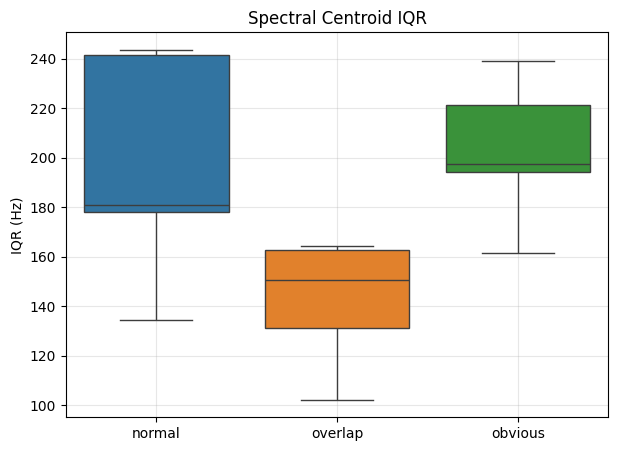

In [86]:
plt.figure(figsize = (7, 5))
sns.boxplot(data = [group_a_stats["centroid_iqr"].values,
                    group_b_stats["centroid_iqr"].values,
                    group_c_stats["centroid_iqr"].values
                   ])
plt.xticks([0, 1, 2], ["normal", "overlap", "obvious"])
plt.ylabel("IQR (Hz)")
plt.title("Spectral Centroid IQR")
plt.grid(alpha = 0.3)
plt.show()

### Delta

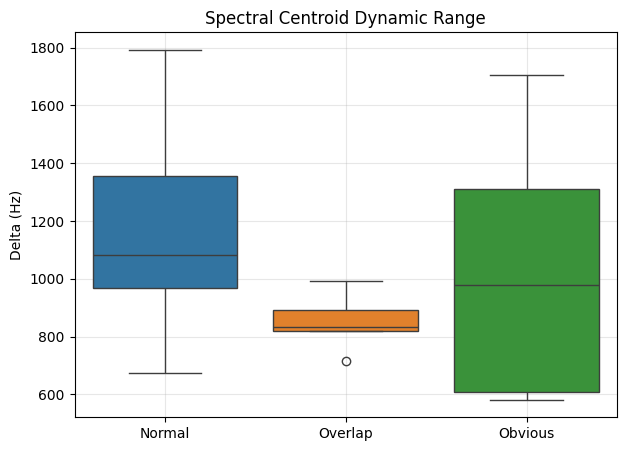

In [87]:
plt.figure(figsize = (7, 5))
sns.boxplot(data = [group_a_stats["centroid_delta"].values,
                    group_b_stats["centroid_delta"].values,
                    group_c_stats["centroid_delta"].values])
plt.xticks([0, 1, 2], ["Normal", "Overlap", "Obvious"])
plt.ylabel("Delta (Hz)")
plt.title("Spectral Centroid Dynamic Range")
plt.grid(alpha = 0.3)
plt.show()

### Scatter Plot

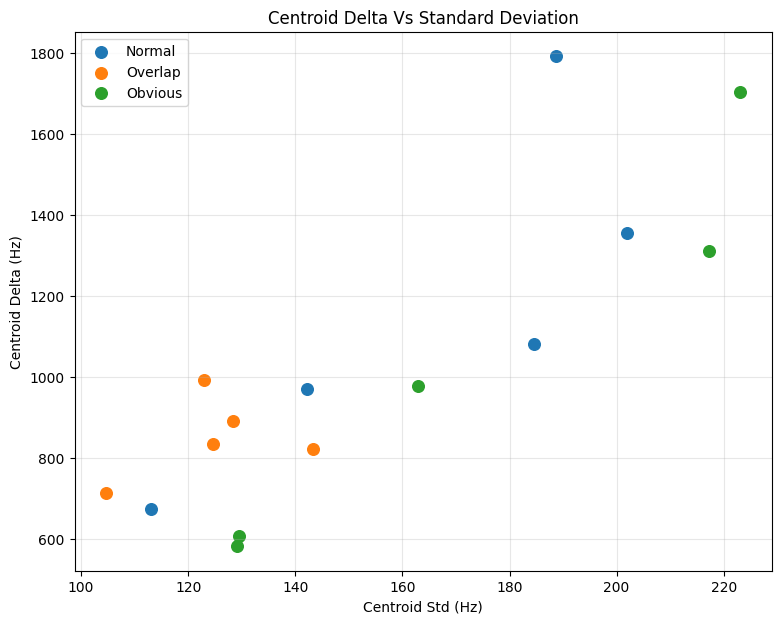

In [88]:
plt.figure(figsize = (9, 7))
plt.scatter(
    group_a_stats.centroid_std,
    group_a_stats.centroid_delta,
    s = 70, label = "Normal"
)
plt.scatter(
    group_b_stats.centroid_std,
    group_b_stats.centroid_delta,
    s = 70, label = "Overlap"
)
plt.scatter(
    group_c_stats.centroid_std,
    group_c_stats.centroid_delta,
    s = 70, label = "Obvious"
)
plt.xlabel("Centroid Std (Hz)")
plt.ylabel("Centroid Delta (Hz)")
plt.title("Centroid Delta Vs Standard Deviation")
plt.grid(alpha = 0.3)
plt.legend()
plt.show()

### Mean vs Std

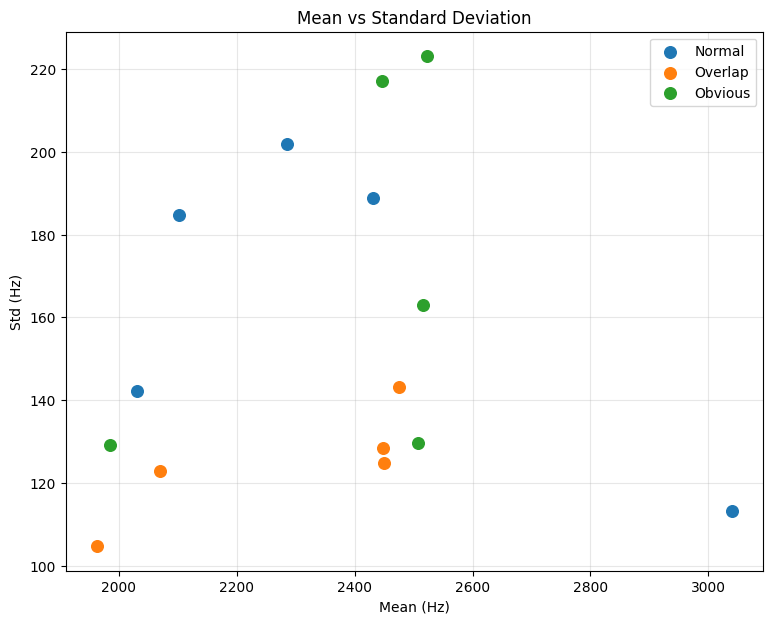

In [89]:
plt.figure(figsize=(9,7))

plt.scatter(
    group_a_stats.centroid_mean,
    group_a_stats.centroid_std,
    s=70,
    label="Normal"
)

plt.scatter(
    group_b_stats.centroid_mean,
    group_b_stats.centroid_std,
    s=70,
    label="Overlap"
)

plt.scatter(
    group_c_stats.centroid_mean,
    group_c_stats.centroid_std,
    s=70,
    label="Obvious"
)

plt.xlabel("Mean (Hz)")
plt.ylabel("Std (Hz)")

plt.title("Mean vs Standard Deviation")

plt.grid(alpha=0.3)

plt.legend()

plt.show()

### Histograms

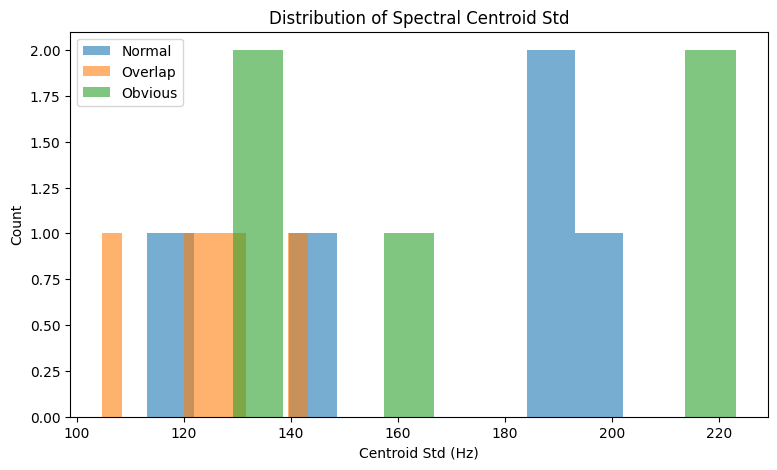

In [91]:
plt.figure(figsize=(9,5))

plt.hist(
    group_a_stats.centroid_std,
    bins=10,
    alpha=0.6,
    label="Normal"
)

plt.hist(
    group_b_stats.centroid_std,
    bins=10,
    alpha=0.6,
    label="Overlap"
)

plt.hist(
    group_c_stats.centroid_std,
    bins=10,
    alpha=0.6,
    label="Obvious"
)

plt.xlabel("Centroid Std (Hz)")
plt.ylabel("Count")

plt.legend()

plt.title("Distribution of Spectral Centroid Std")

plt.show()

### Correlation Heatmap (on Entire Dataset)

In [7]:
centroid_summary = centroid_summary.merge(rms_summary, 
                                          on = ["file_name", "label"])

In [104]:
centroid_summary = centroid_summary.drop(columns = ['rms_x', 'rms_y'])

In [107]:
centroid_summary.head()

,centroid_mean,centroid_std,centroid_min,centroid_max,centroid_delta,centroid_q25,centroid_q75,centroid_iqr,file_name,label,rms
0,2377.057822,203.249647,1962.135768,3639.686883,1677.551115,2243.546767,2495.872024,252.325257,00000000.wav,Normal,0.006863
1,2615.976632,163.012387,2204.683950,3477.425155,1272.741205,2504.840504,2701.621417,196.780913,00000001.wav,Normal,0.006892
2,2420.451821,221.444349,1879.446225,3125.582353,1246.136128,2277.626044,2554.681328,277.055284,00000002.wav,Normal,0.007001
3,2640.560590,143.981090,2293.331119,3325.892444,1032.561324,2548.801170,2723.995983,175.194813,00000003.wav,Normal,0.006864
4,2363.787353,161.885214,2017.350298,3058.560910,1041.210611,2262.940960,2441.204920,178.263960,00000004.wav,Normal,0.006833


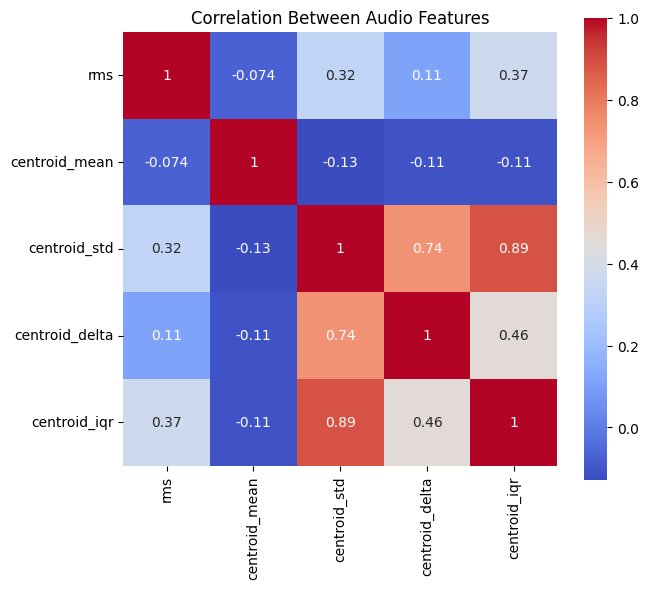

In [106]:
features = [
    "rms",
    "centroid_mean", 
    "centroid_std", 
    "centroid_delta",
    "centroid_iqr"
]
plt.figure(figsize = (7, 6))
sns.heatmap(centroid_summary[features].corr(),
            annot = True,
            cmap = "coolwarm",
            square = True
           )
plt.title("Correlation Between Audio Features")
plt.show()

### Key Observations

* <b>Individual trajectories look deceptively similar across groups - </b>ormal and Overlap files show comparable centroid ranges and smooth baseline shapes; only Obvious anomaly files show visibly more jagged, high-amplitude oscillation on inspection alone.
* <b>Overlap(subtle) anomalies are characterized by reduced variability, not increased - </b>They show the lowest std, IQR, and dynamic range of all three groups, making them behave like a "quiter, more stable" version of normal rather than an obviously disturbed signal. This is why they're easy to miss visually.
* <b>Obvious anomalies are marked by a combination of eleve=ated mean centroid and high variability - </b>they shift toward higher frequency content while also being more erratic, which is what makes them visually and statistically distinct.
* <b>Mean centroid and variability (std/IQR/delta) behave as two independent axes - </b> correlation analysis confirms cntroid_mean is nearly uncorrelated with std/IQR/delta (-0.11 to -0.13), while std, IQR and delta are strongly inter-correlated (0.74 - 0.89), meaning they capture largely the same "spectral instability" property rather than adding independent information.
* <b>practical implementation for classification - </b> Normal vs Overlap separation relies more on variability features (std, IQR, delta), while Overlap/Normal vs Obvious separation relies more on mean centroid shft. A minimal, low-redundancy feature set would be {centroid_mean, centroid_std, rms}.
* <b>Full-dataset statistics show a blended pattern - </b>Abnormal has only a slightly lower mean but much higher variance-of-variance (std, IQR, delta all show far large spread), consistent with the abnormal class being a mix of subtle (low-variability) and obvious (high-variability) anomalies rather than a single homogeneous anomaly type.

This motivates moving beyond first-order spectral descriptors toward higher-dimensional representations such as MFCCs.